# Matplotlib 2 - Advanced

> **MLCourse · Data Science Foundations · 03_matplotlib**

Now we compose: multi-panel dashboards, dual axes, images and heatmaps, log
scales, themes, colormaps and 3-D. This is the toolbox behind every polished
figure you have admired.

### What you'll learn
- The object-oriented interface as a system (not an idiom)
- Subplots grids + `subplot_mosaic` layout design
- Twin/secondary axes for two-unit comparisons
- Images with `imshow`, 2-D fields (`pcolormesh`, `contourf`), dense-scatter fixes
- Error bars & uncertainty bands
- Log scales that reveal power laws
- Styles, `rcParams`, colormap selection theory
- Plotting straight from DataFrames; 3-D surfaces

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100

### 1. The OO interface as a mental model

Every pyplot function is a thin wrapper over Axes methods. Learn the mapping and
the wrapper becomes optional:

In [2]:
mapping = pd.DataFrame({
    "pyplot": ["plt.plot", "plt.title", "plt.xlabel", "plt.legend",
               "plt.xlim", "plt.xticks", "plt.grid", "plt.savefig"],
    "Axes method": ["ax.plot", "ax.set_title", "ax.set_xlabel", "ax.legend",
                    "ax.set_xlim", "ax.set_xticks", "ax.grid", "fig.savefig"],
})
mapping   # rendered as a table in Jupyter

,pyplot,Axes method
0,plt.plot,ax.plot
1,plt.title,ax.set_title
2,plt.xlabel,ax.set_xlabel
3,plt.legend,ax.legend
4,plt.xlim,ax.set_xlim
5,plt.xticks,ax.set_xticks
6,plt.grid,ax.grid
7,plt.savefig,fig.savefig


> 💡 **Pro tip:** `ax.set(xlabel=..., title=..., ylim=...)` sets several
properties in one call - tidy for standard figures.

### 2. Subplot grids & mosaics


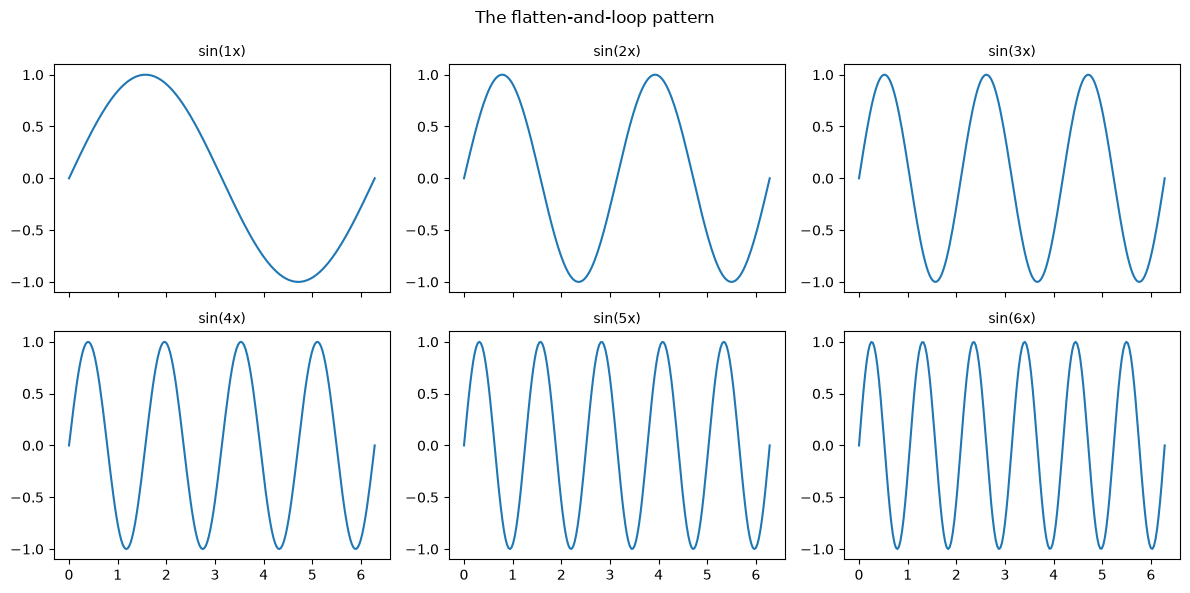

In [3]:
# A 2×3 grid via the axes-array pattern:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)   # shared x-scale
xs = np.linspace(0, 2 * np.pi, 200)

for i, ax_row in enumerate(axes):          # iterate ROWS...
    for j, ax in enumerate(ax_row):        # ...then columns -> flat index k
        k = i * 3 + j + 1
        ax.plot(xs, np.sin(k * xs))
        ax.set_title(f"sin({k}x)", fontsize=10)

fig.suptitle("The flatten-and-loop pattern")
fig.tight_layout()
plt.show()

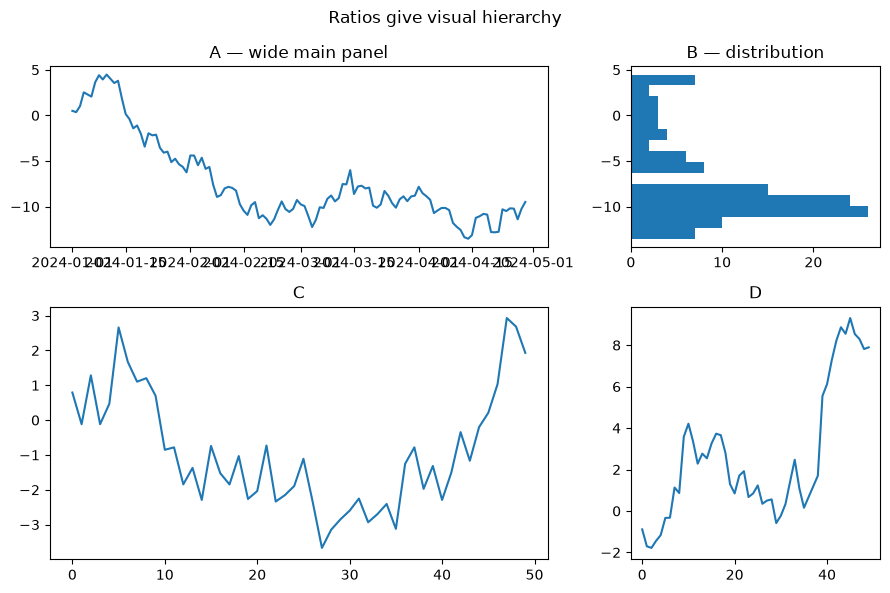

In [4]:
# subplot_mosaic: draw the LAYOUT as ASCII art - modern and self-documenting.
fig, mosaic = plt.subplot_mosaic(
    [["A", "B"],
     ["C", "D"]],
    figsize=(9, 6),
    gridspec_kw={"width_ratios": [2, 1], "height_ratios": [1, 1.4]},  # column widths
)
ax_big, ax_side = mosaic["A"], mosaic["B"]
ax_bot, ax_bot2 = mosaic["C"], mosaic["D"]

t = pd.date_range("2024-01-01", periods=120)
series = np.cumsum(np.random.randn(120)) 

ax_big.plot(t, series); ax_big.set_title("A - wide main panel")
ax_side.hist(series, bins=15, orientation="horizontal"); ax_side.set_title("B - distribution")
for ax_, lbl in [(ax_bot, "C"), (ax_bot2, "D")]:
    ax_.plot(np.random.randn(50).cumsum()); ax_.set_title(lbl)

fig.suptitle("Ratios give visual hierarchy")
fig.tight_layout()
plt.show()

### 3. Twin & secondary axes


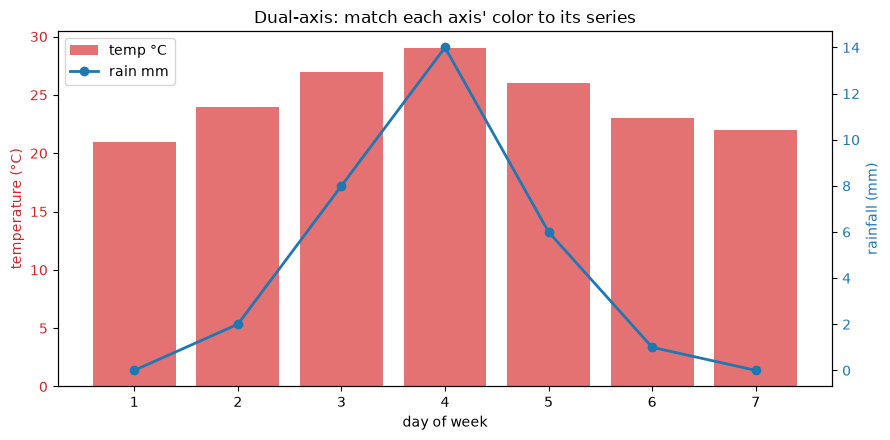

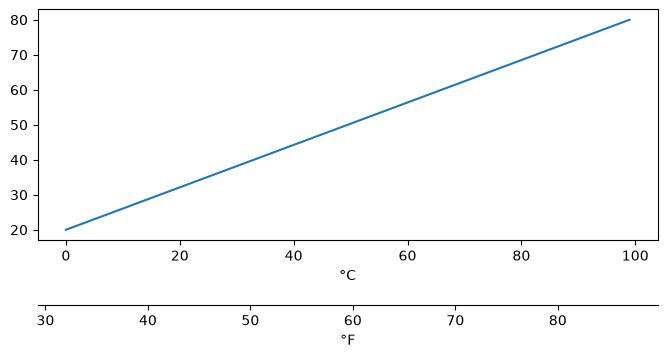

In [5]:
days = np.arange(1, 8)
celsius = np.array([21, 24, 27, 29, 26, 23, 22])
rain = np.array([0, 2, 8, 14, 6, 1, 0])

fig, ax_t = plt.subplots(figsize=(9, 4.5))

# Left axis: temperature bars
ax_t.bar(days, celsius, color="tab:red", alpha=0.65, label="temp °C")
ax_t.set_ylabel("temperature (°C)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")

# Right axis: a SECOND y-scale sharing the same x
ax_r = ax_t.twinx()
ax_r.plot(days, rain, color="tab:blue", marker="o", lw=2, label="rain mm")
ax_r.set_ylabel("rainfall (mm)", color="tab:blue")
ax_r.tick_params(axis="y", labelcolor="tab:blue")

# Merge legends from BOTH axes:
h1, l1 = ax_t.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax_t.legend(h1 + h2, l1 + l2, loc="upper left")

ax_t.set_title("Dual-axis: match each axis' color to its series")
ax_t.set_xlabel("day of week")
fig.tight_layout()
plt.show()

# secondary_xaxis converts units on the fly (forward/inverse functions):
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(0, 100), np.linspace(20, 80, 100))
secx = ax.secondary_xaxis(-0.28, functions=(lambda f: f * 5 / 9 + 32,   # °F from °C
                                            lambda c: (c - 32) * 5 / 9))
ax.set_xlabel("°C"); secx.set_xlabel("°F")
plt.show()

> ⚠️ **Common pitfall:** dual axes invite misreading (which line belongs to
which scale?). Color-code axis labels/ticks to their series - as above.

### 4. Images & 2-D fields


### Any 2-D array can be shown as an image:


In [ ]:
yy, xx = np.mgrid[0:200, 0:300]                       # coordinate grids
image = np.sin(xx / 18) * np.cos(yy / 14)             # smooth interference pattern
noisy = image + np.random.normal(0, 0.08, image.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

im0 = axes[0].imshow(image, cmap="twilight")          # default origin='upper'
axes[0].set_title("imshow default")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(noisy[::4, ::4],                 # downsampled view
                     interpolation="nearest",         # no smoothing of pixels
                     extent=[0, 30, 0, 20])           # real-world coordinates
axes[1].set_title("extent maps pixels → data coords")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].contourf(xx[:150, :150], yy[:150, :150],
                       image[:150, :150], levels=14, cmap="viridis")
axes[2].set_title("contourf = filled level curves")
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

# pcolormesh ≈ imshow but works with irregular x/y grids - mention, not master.


### Dense scatter? Go 2-D.


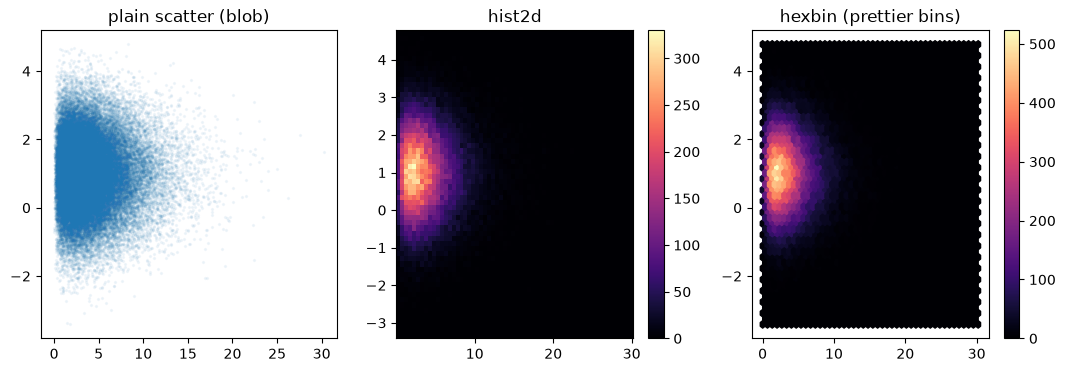

In [7]:
n = 60_000                                        # far too many points to overplot
dense = pd.DataFrame({
    "x": np.random.gamma(2.0, 2.0, n),
    "y": np.random.normal(np.sqrt(1), 1.0, n) ,
})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(dense["x"], dense["y"], s=2, alpha=0.05)      # alpha alone struggles
axes[0].set_title("plain scatter (blob)")

h = axes[1].hist2d(dense["x"], dense["y"], bins=60, cmap="magma")
axes[1].set_title("hist2d"); fig.colorbar(h[3], ax=axes[1])

hb = axes[2].hexbin(dense["x"], dense["y"], gridsize=45, cmap="magma")
axes[2].set_title("hexbin (prettier bins)"); fig.colorbar(hb, ax=axes[2])
plt.show()

### 5. Error bars & uncertainty bands


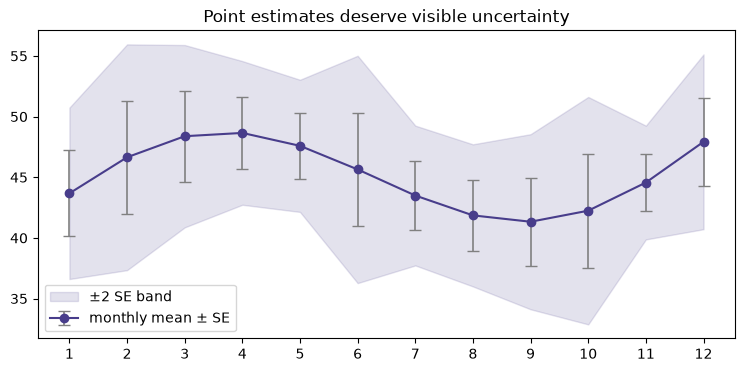

In [8]:
months = np.arange(1, 13)
mean_sales = 40 + 6 * np.sin(months / 2) + months * 0.8
std_err = np.random.uniform(2, 5, 12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(months, mean_sales, yerr=std_err,
            fmt="o-", capsize=4, color="darkslateblue",
            ecolor="gray", elinewidth=1.2, label="monthly mean ± SE")

# fill_between paints a band - great for confidence intervals around lines:
lower, upper = mean_sales - 2*std_err, mean_sales + 2*std_err
ax.fill_between(months, lower, upper, color="darkslateblue", alpha=0.15,
                label="±2 SE band")
ax.set_xticks(months)
ax.set_title("Point estimates deserve visible uncertainty")
ax.legend()
plt.show()

### 6. Log scales - when magnitude spans decades


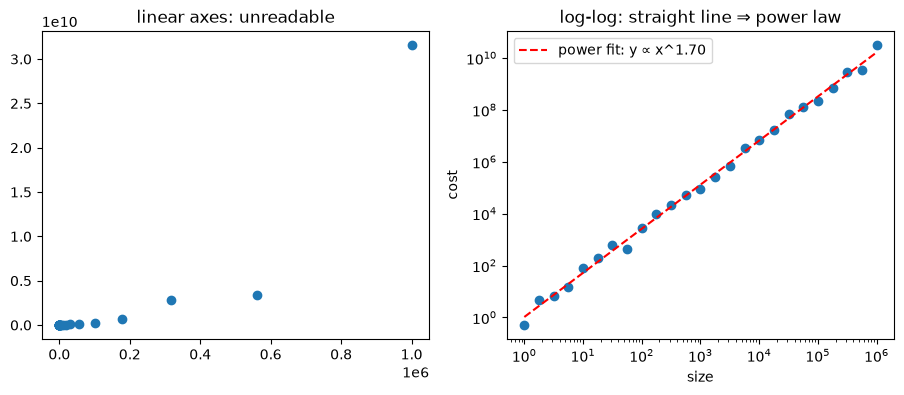

In [9]:
n_pow = 25
sizes = np.geomspace(1, 1e6, n_pow)              # geometric sequence 1..10^6
cost = sizes ** 1.7 * np.exp(np.random.normal(0, .35, n_pow))   # power law + noise

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(sizes, cost, "o")                    # linear axes hide everything
axes[0].set_title("linear axes: unreadable")

axes[1].loglog(sizes, cost, "o")                  # both axes log
# Fit slope in LOG space: log(y) = b*log(x) + a  ->  slope = exponent!
b_fit, a_fit = np.polyfit(np.log10(sizes), np.log10(cost), 1)
xs_fit = np.geomspace(sizes.min(), sizes.max(), 50)
axes[1].loglog(xs_fit, 10**a_fit * xs_fit**b_fit, "r--",
               label=f"power fit: y ∝ x^{b_fit:.2f}")
axes[1].legend()
axes[1].set_title("log-log: straight line ⇒ power law")
axes[1].set_xlabel("size"); axes[1].set_ylabel("cost")
plt.show()

# semilogx/semilogy scale ONE axis; symlog handles values crossing zero.

### 7. Styles & rcParams - global look and feel


In [10]:
print(sorted(plt.style.available)[:12], "...")

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8'] ...


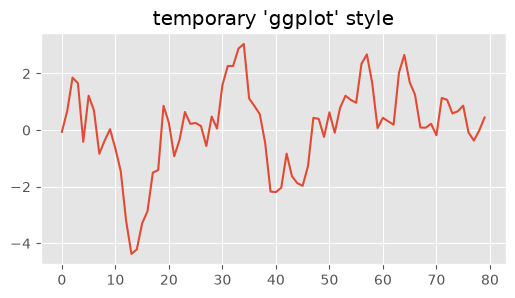

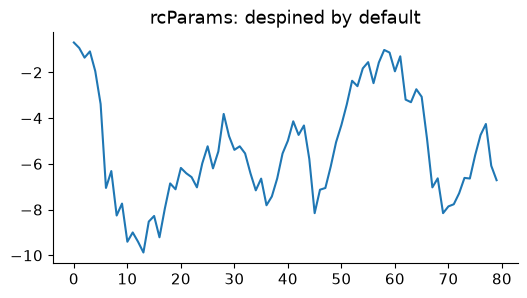

In [11]:
with plt.style.context("ggplot"):                 # context manager: temporary style
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(np.cumsum(np.random.randn(80)))
    ax.set_title("temporary 'ggplot' style")
    plt.show()

# rcParams = persistent defaults dictionary:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,       # hide top spine globally...
    "axes.spines.right": False,     # ...the manual 'despine' recipe
    "figure.facecolor": "white",
})
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.cumsum(np.random.randn(80))); ax.set_title("rcParams: despined by default")
plt.show()
plt.rcParams.update(plt.rcParamsDefault)          # restore factory settings

### 8. Choosing colormaps deliberately


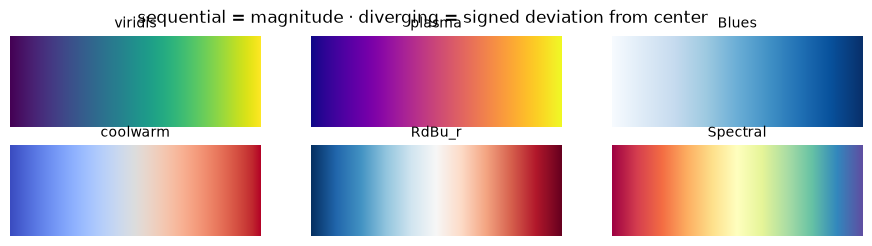

In [12]:
gradient = np.linspace(0, 1, 256).reshape(1, -1)

cmaps = [("sequential", ["viridis", "plasma", "Blues"]),
         ("diverging", ["coolwarm", "RdBu_r", "Spectral"])]

fig, axes = plt.subplots(2, 3, figsize=(11, 2.6))
for row, (kind, names) in enumerate(cmaps):
    for col, name in enumerate(names):
        axes[row, col].imshow(gradient, aspect="auto", cmap=name)
        axes[row, col].set_title(name, fontsize=10)
        axes[row, col].axis("off")
fig.suptitle("sequential = magnitude · diverging = signed deviation from center")
plt.show()

# Rules: perceptually-uniform (viridis family) for science; diverging when zero
# matters (correlations); never rainbow ('jet') - it distorts perceived order.

### 9. Plotting directly from pandas


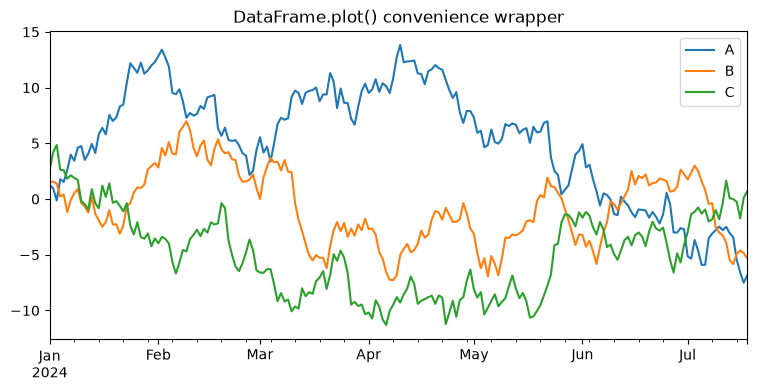

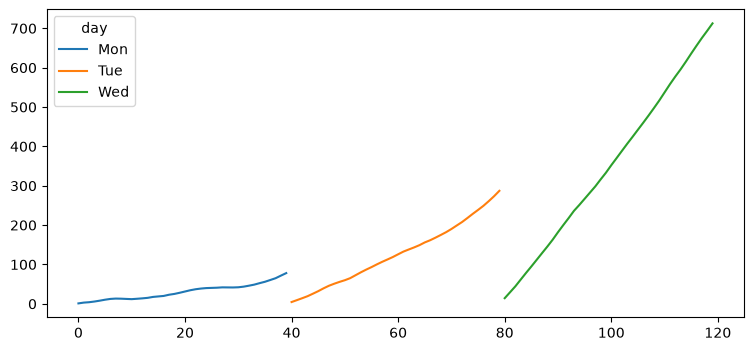

In [13]:
df = pd.DataFrame({
    "A": np.cumsum(np.random.randn(200)),
    "B": np.cumsum(np.random.randn(200)),
    "C": np.cumsum(np.random.randn(200)),
}, index=pd.date_range("2024-01-01", periods=200))

df.plot(figsize=(9, 4), lw=1.5)                   # thin wrapper over our tools
plt.title("DataFrame.plot() convenience wrapper")
plt.show()

# Grouped-to-lines pattern without the wrapper:
fig, ax = plt.subplots(figsize=(9, 4))
for key, grp in df.groupby(df.index.quarter):
    pass                                          # demo only - real grouping below
tips_like = pd.DataFrame({"day": np.repeat(["Mon","Tue","Wed"], 40),
                          "val": np.random.randn(120).cumsum()})
for day, grp in tips_like.groupby("day"):
    ax.plot(grp.index, grp["val"].cumsum(), label=day)     # one line per group
ax.legend(title="day")
plt.show()

### 10. 3-D plots


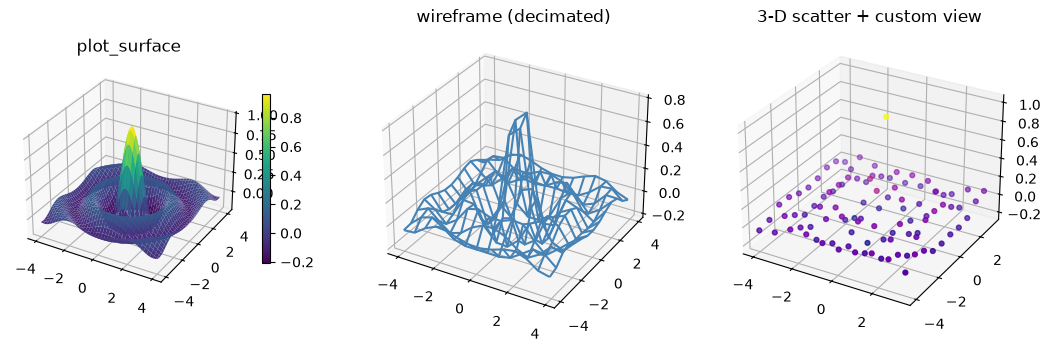

In [14]:
from mpl_toolkits.mplot3d import Axes3D           # noqa: F401 (registers projection)

X = np.linspace(-4, 4, 80)
Y = np.linspace(-4, 4, 80)
Xg, Yg = np.meshgrid(X, Y)                        # 2-D coordinate matrices
Zg = np.sinc(np.sqrt(Xg**2 + Yg**2))              # radial sinc surface

fig = plt.figure(figsize=(13, 4))

ax1 = fig.add_subplot(131, projection="3d")
surf = ax1.plot_surface(Xg, Yg, Zg, cmap="viridis", linewidth=0)
fig.colorbar(surf, ax=ax1, shrink=0.55)
ax1.set_title("plot_surface")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_wireframe(Xg[::6, ::6], Yg[::6, ::6], Zg[::6, ::6], color="steelblue")
ax2.set_title("wireframe (decimated)")

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(Xg[::8, ::8], Yg[::8, ::8], Zg[::8, ::8],
            c=Zg[::8, ::8], cmap="plasma", s=12)
ax3.view_init(elev=28, azim=-60)                  # camera angle control
ax3.set_title("3-D scatter + custom view")
plt.show()

### Animation pointer

`matplotlib.animation.FuncAnimation(fig, update_func, frames=...)` redraws an
artist per frame; export with `ani.save("anim.mp4", writer="ffmpeg")`. It needs
ffmpeg installed - out of scope here, see official docs gallery.

### Summary & key takeaways

- pyplot ↔ Axes mapping table frees you to mix interfaces safely.
- Design layouts with `subplots` grids or `subplot_mosaic` ASCII art +
  width/height ratios; loop over the flattened array.
- `twinx`/`secondary_axis` compare different units - color-match axes to series.
- `imshow` shows any matrix; `extent` gives it data coordinates; use `hexbin`/
  `hist2d` when scatter saturates.
- Always visualize uncertainty: `errorbar`, `fill_between`.
- Log-log turns power laws into straight lines whose SLOPE is the exponent
  (`polyfit` on logs).
- Control house style via styles/context managers and `rcParams`; despine by
  hiding top/right spines.
- Pick colormaps by DATA TYPE: sequential for magnitude, diverging for signed
  values, viridis-family always safe.
- `df.plot()` is a convenience wrapper; groupby-loop gives full control.
- 3-D = add `projection="3d"`; steer the camera with `view_init`.